In [1]:
import pandas
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [2]:
training_data = pandas.read_csv('features_train_70000.csv')
testing_data = pandas.read_csv('features_test_70000.csv') 

In [3]:
training_data.head(10)

,Kurtosis,Skewness,Std,Range,Median,Geometric_Mean,Mobility,Complexity,Tag
0,15.0238,2.91000,274.7740,1789,228.0,160.4439,0.147740,0.8579,0
1,2.8010,0.92232,235.7319,917,179.0,145.3054,0.120090,1.2987,0
2,3.9885,0.88732,174.5089,817,260.0,182.6219,0.200340,1.5965,0
3,5.4531,1.83640,343.9752,1336,69.5,120.5608,0.083738,1.2973,0
4,15.8010,3.38050,443.4495,2785,118.0,113.9388,0.231590,1.2115,0
5,2.0605,0.84796,336.7412,1055,17.0,56.6252,0.072721,1.3074,0
6,49.7006,6.30860,358.5921,3501,175.0,190.3360,0.584970,1.4512,0
7,4.9390,1.73780,348.4922,1544,103.5,110.6100,0.195400,1.5202,0
8,3.0864,0.85971,239.3772,1049,199.5,137.5129,0.156110,1.4071,0
9,20.7576,2.98150,188.2063,1751,202.5,205.5073,0.328810,1.1993,0


In [4]:
testing_data.head(10)

,Kurtosis,Skewness,Std,Range,Median,Geometric_Mean,Mobility,Complexity,Tag
0,2.6629,0.89102,163.6614,630,201.5,208.3995,0.153760,1.59810,0
1,2.6006,0.91121,290.5423,963,142.0,88.5387,0.078463,1.52520,0
2,2.8175,0.99971,320.6575,1187,10.5,37.5651,0.149740,1.26250,0
3,14.7654,3.40910,576.6068,3474,50.0,79.9371,0.256130,1.42100,0
4,50.4213,6.72800,1354.7782,11733,14.5,17.0537,0.356650,0.70411,0
5,218.8994,14.26770,612.3959,9616,172.0,182.4440,0.832010,0.59999,0
6,32.8325,4.96960,530.1976,4659,107.0,106.7406,0.324160,1.05290,0
7,4.9430,1.38720,245.5722,1223,214.5,124.8743,0.236110,1.51680,0
8,7.9680,2.25360,418.5519,2241,39.5,46.6549,0.278090,1.52260,0
9,5.8202,1.99170,401.4969,1488,116.5,92.6078,0.082588,1.06230,0


In [5]:
print(training_data.shape)
testing_data.shape

(55999, 9)


(13999, 9)

In [6]:
print(training_data.info)
testing_data.info

<bound method DataFrame.info of        Kurtosis   Skewness       Std   Range   Median   Geometric_Mean  \
0       15.0238    2.91000  274.7740    1789    228.0         160.4439   
1        2.8010    0.92232  235.7319     917    179.0         145.3054   
2        3.9885    0.88732  174.5089     817    260.0         182.6219   
3        5.4531    1.83640  343.9752    1336     69.5         120.5608   
4       15.8010    3.38050  443.4495    2785    118.0         113.9388   
...         ...        ...       ...     ...      ...              ...   
55994    5.0543    1.22740  172.0252     981    238.0         205.0903   
55995   89.9023    8.30370  614.5032    7673    122.5         100.0387   
55996    7.5518    2.03290  279.6423    1520    156.0         137.6493   
55997   34.0220    4.80400  416.7042    3971    116.5         139.1423   
55998   20.0341    3.68640  457.0151    3333     86.5          82.4291   

        Mobility   Complexity   Tag  
0       0.147740       0.8579     0  
1  

<bound method DataFrame.info of        Kurtosis   Skewness        Std   Range   Median   Geometric_Mean  \
0        2.6629    0.89102   163.6614     630    201.5         208.3995   
1        2.6006    0.91121   290.5423     963    142.0          88.5387   
2        2.8175    0.99971   320.6575    1187     10.5          37.5651   
3       14.7654    3.40910   576.6068    3474     50.0          79.9371   
4       50.4213    6.72800  1354.7782   11733     14.5          17.0537   
...         ...        ...        ...     ...      ...              ...   
13994    5.7543    1.75700   296.9301    1412    141.5         124.8764   
13995    3.4971    1.32400   274.3121     981    166.0         138.2617   
13996  131.4396   10.62380   614.7710    8413    163.0         165.4823   
13997    9.0004    2.33100   313.3685    1823    183.0         126.3378   
13998    5.3811    1.74460   357.8384    1644     81.5         104.7555   

        Mobility   Complexity   Tag  
0       0.153760      1.59810

In [7]:
print(training_data.isnull().sum())
print(testing_data.isnull().sum())

print("duplicate: ",training_data.duplicated().sum())
print("duplicate: ",testing_data.duplicated().sum())



Kurtosis           0
 Skewness          0
 Std               0
 Range             0
 Median            0
 Geometric_Mean    0
 Mobility          0
 Complexity        0
 Tag               0
dtype: int64
Kurtosis           0
 Skewness          0
 Std               0
 Range             0
 Median            0
 Geometric_Mean    0
 Mobility          0
 Complexity        0
 Tag               0
dtype: int64
duplicate:  1
duplicate:  0


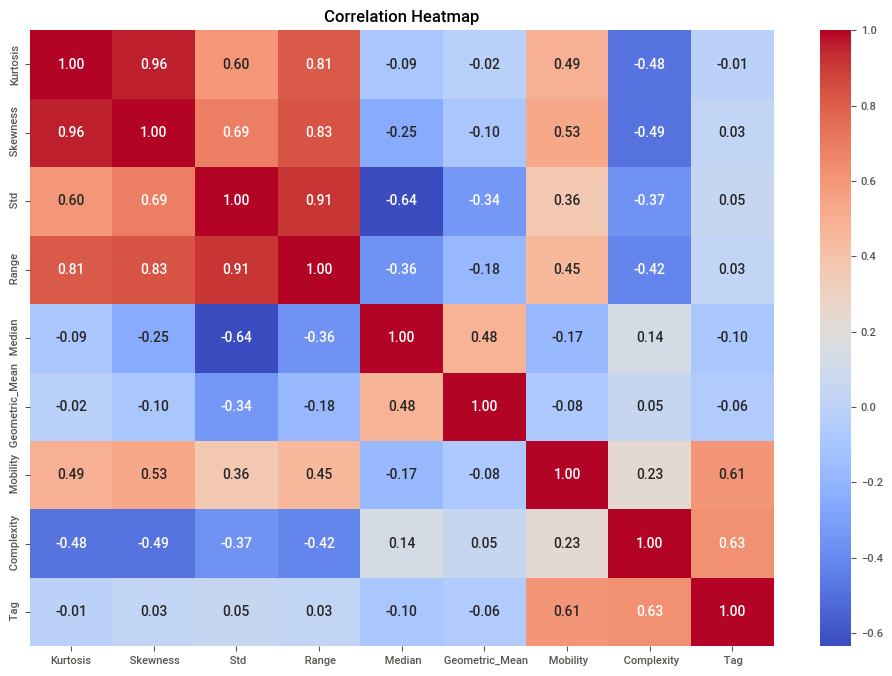

In [88]:
plt.figure(figsize=(12, 8))
sns.heatmap(training_data.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [89]:
!pip install sweetviz

In [50]:
import sweetviz as sv
my_report = sv.analyze(training_data)
my_report.show_html('sweetviz_report.html')

                                             |          | [  0%]   00:00 -> (? left)

Report sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [90]:
x_train, y_train = training_data.drop([' Tag'], axis=1), training_data[' Tag']
x_test, y_test = testing_data.drop([' Tag'], axis=1), testing_data[' Tag']

scaler = preprocessing.MinMaxScaler(feature_range=(0, 1))
x_train, x_test = scaler.fit_transform(x_train), scaler.fit_transform(x_test) 

In [91]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

In [92]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)

In [93]:
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'LR': lrc, 
    'RF': rfc}

In [94]:
def train_classifier(clf,x_train,y_train,x_test,y_test):
    clf.fit(x_train,y_train)
    y_pred = clf.predict(x_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    
    return {'accuracy': accuracy, 'precision': precision}

In [ ]:
accuracy_scores= []
precision_scores= []

for name,clf in clfs.items():
    
       result = train_classifier(clf, x_train, y_train, x_test, y_test)
       print("For", name)
       print("Accuracy: ", result['accuracy'])
       print("Precision: ", result['precision'])

       accuracy_scores.append(result['accuracy'])
       precision_scores.append(result['precision'])

In [ ]:
performance_df = pandas.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)
performance_df

In [ ]:
performance_df1 = pandas.melt(performance_df, id_vars = "Algorithm")
performance_df1

In [ ]:
sns.catplot(x = 'Algorithm', y='value', 
               hue = 'variable',data=performance_df1, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

In [ ]:
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
knc =  KNeighborsClassifier()
lrc = LogisticRegression(solver='liblinear', penalty='l1')


from sklearn.ensemble import VotingClassifier
voting = VotingClassifier(estimators=[('RF', rfc), ('KN', knc), ('LR', lrc)],voting='soft')

In [ ]:
voting.fit(x_train,y_train)

In [ ]:
y_pred = voting.predict(x_test)
print("Accuracy of Voting Classifier",accuracy_score(y_test,y_pred))
print("Precision of Voting Classifier",precision_score(y_test,y_pred))

In [ ]:
print("\n--- Confusion Matrix ---")
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()